In [1]:
import pandas as pd
import numpy as np

import re # Regular Expression 
import nltk
from nltk.corpus import stopwords 
from nltk.stem.porter import PorterStemmer # Lemmatization/Stemming

# Vektörizasyon 
from sklearn.feature_extraction.text import CountVectorizer # Bag of Words 

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Rojin
[nltk_data]     Koç\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# quoting=3 parametresi, metinlerin içindeki çift tırnakların (" ") kodda hata vermesini engeller
dataset = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)

print("Veri Setinin İlk 5 Satırı:")
print(dataset.head())
print("\n" + "="*50 + "\n")

Veri Setinin İlk 5 Satırı:
                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1




In [3]:
# Regular Expression (RE)
ilk_yorum = dataset['Review'][0]
print(f"Orijinal Yorum: {ilk_yorum}")

# Sadece a'dan z'ye ve A'dan Z'ye olan harfleri tut. 
# Geri kalan her şeyi (nokta, virgül, sayı, ünlem, emoji vb.) boşlukla değiştir.
temiz_yorum = re.sub('[^a-zA-Z]', ' ', ilk_yorum)

temiz_yorum = temiz_yorum.lower()

print(f"Temizlenmiş Yorum: {temiz_yorum}")

Orijinal Yorum: Wow... Loved this place.
Temizlenmiş Yorum: wow    loved this place 


In [ ]:
# Temizlenmiş yorumları tutacağımız boş listemiz
corpus = []

# Kelimeleri köküne indir (PorterStemmer) 
ps = PorterStemmer()

# İngilizce'deki gereksiz kelimeler (stopwords) listesini alıyoruz
all_stopwords = stopwords.words('english')

# "not" kelimesini gereksiz kelimeler listesinden ÇIKARIYORUZ.
# Eğer bunu yapmazsak algoritma "not good" (iyi değil) yorumundaki "not" kelimesini siler 
# ve restoranı "good" zannedip olumlu puan verir!
all_stopwords.remove('not')

for i in range(0, len(dataset)):
    yorum = re.sub('[^a-zA-Z]', ' ', dataset['Review'][i])
    yorum = yorum.lower()
    
    yorum = yorum.split() #word_tokenize()
    
    yorum = [ps.stem(kelime) for kelime in yorum if not kelime in set(all_stopwords)]
    
    yorum = ' '.join(yorum)
    
    corpus.append(yorum)

In [5]:
print("İşte Tüm Veri Setinin Temizlenmiş İlk 5 Yorumu:")
for i in range(5):
    print(f"{i+1}. Orijinal: {dataset['Review'][i]}")
    print(f"   Temiz   : {corpus[i]}\n")

İşte Tüm Veri Setinin Temizlenmiş İlk 5 Yorumu:
1. Orijinal: Wow... Loved this place.
   Temiz   : wow love place

2. Orijinal: Crust is not good.
   Temiz   : crust not good

3. Orijinal: Not tasty and the texture was just nasty.
   Temiz   : not tasti textur nasti

4. Orijinal: Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.
   Temiz   : stop late may bank holiday rick steve recommend love

5. Orijinal: The selection on the menu was great and so were the prices.
   Temiz   : select menu great price



In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# en sık kullanılan 1500 kelimeyi sütun yap
cv = CountVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()
y = dataset['Liked'].values

print(f"X (Özellikler) Matrisinin Boyutu: {X.shape}")

X (Özellikler) Matrisinin Boyutu: (1000, 1500)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

# Naive Bayes Modeli
classifier = GaussianNB()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [9]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Karmaşıklık Matrisi (Confusion Matrix):")
print(cm)
print(f"\nModelin Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}")

Karmaşıklık Matrisi (Confusion Matrix):
[[55 42]
 [12 91]]

Modelin Doğruluk Oranı (Accuracy): %73.00


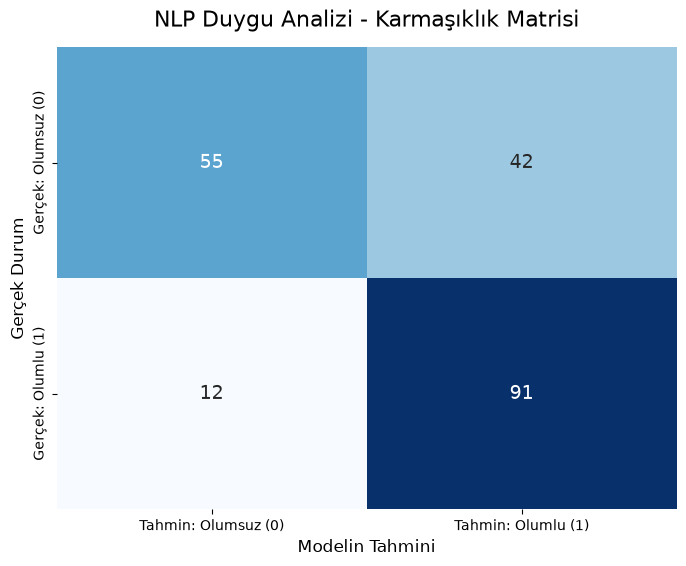

In [11]:
plt.figure(figsize=(8, 6))


sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Tahmin: Olumsuz (0)', 'Tahmin: Olumlu (1)'], 
    yticklabels=['Gerçek: Olumsuz (0)', 'Gerçek: Olumlu (1)'],
    cbar=False,
    annot_kws={"size": 14} 
)

plt.title('NLP Duygu Analizi - Karmaşıklık Matrisi', fontsize=16, pad=15)
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Durum', fontsize=12)
plt.show()

In [ ]:


# Temizlenmiş corpus listemizi ve 1/0'lardan oluşan y hedefimizi bir DataFrame'de birleştiriyoruz
df_gorsel = pd.DataFrame({'Temiz_Metin': corpus, 'Duygu': y})

# 1 (Olumlu) ve 0 (Olumsuz) yorumları kendi içlerinde devasa tek bir metin haline getiriyoruz
olumlu_metinler = " ".join(df_gorsel[df_gorsel['Duygu'] == 1]['Temiz_Metin'])
olumsuz_metinler = " ".join(df_gorsel[df_gorsel['Duygu'] == 0]['Temiz_Metin'])

# WordCloud nesnelerini oluşturuyoruz (Olumlular yeşil, olumsuzlar kırmızı tonlarda)
wc_olumlu = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(olumlu_metinler)
wc_olumsuz = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(olumsuz_metinler)

# Yan yana iki grafik çizdirme ayarları
plt.figure(figsize=(16, 8))

# 1. Grafik: Olumlu Yorumlar
plt.subplot(1, 2, 1)
plt.imshow(wc_olumlu, interpolation='bilinear')
plt.title('Olumlu Yorumlar (1) - En Sık Geçen Kelimeler', fontsize=16, color='green', pad=15)
plt.axis('off') # Eksen çizgilerini kapatıyoruz

# 2. Grafik: Olumsuz Yorumlar
plt.subplot(1, 2, 2)
plt.imshow(wc_olumsuz, interpolation='bilinear')
plt.title('Olumsuz Yorumlar (0) - En Sık Geçen Kelimeler', fontsize=16, color='red', pad=15)
plt.axis('off')

plt.tight_layout()
plt.show()